In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

# Load Data (Streaming Mode)
print("Setting up streams...")
dataset_name = "OpenDataDetector/ColliderML_ttbar_pu0"
particles_stream = load_dataset(dataset_name, "particles", split="train", streaming=True)
tracker_hits_stream = load_dataset(dataset_name, "tracker_hits", split="train", streaming=True)
calo_hits_stream = load_dataset(dataset_name, "calo_hits", split="train", streaming=True)

# Isolate the First Shard
# We get the total number of shards (files) from the dataset object
# and request index=0 (the first file).
n_shards = particles_stream.n_shards
print(f"Dataset has {n_shards} shards. Isolating shard 0...")

particles_shard0 = particles_stream.shard(num_shards=n_shards, index=0)
tracker_shard0 = tracker_hits_stream.shard(num_shards=n_shards, index=0)
calo_shard0 = calo_hits_stream.shard(num_shards=n_shards, index=0)

/Users/finn/miniforge3/envs/collider-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting up streams...
Dataset has 100 shards. Isolating shard 0...


In [ ]:
import sys
import os
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from fast_association_matrix import fast_sparse_association_matrix

# Create an iterator that we can query on demand
stream_iterator = zip(particles_shard0, tracker_shard0, calo_shard0)
q
def get_next_batch_of_results(iterator, batch_size=5):
    """
    Fetches raw data, processes it, and returns the results.
    """
    p_batch, t_batch, c_batch = [], [], []
    
    # Try to fetch batch_size elements from the stream
    try:
        for _ in range(batch_size):
            p, t, c = next(iterator)
            p_batch.append(p)
            t_batch.append(t)
            c_batch.append(c)
    except StopIteration:
        pass # Handle end of stream
    
    if not p_batch:
        return None # Stream is empty

    results = fast_sparse_association_matrix(
        particles=p_batch,
        tracker_hits=t_batch,
        calo_hits=c_batch,
        radius_threshold=2.0
    )
    return results

print("Generator ready: Run the next cell to see plots.")

Generator ready: Run the next cell to see plots.


Plotting next 5 events...


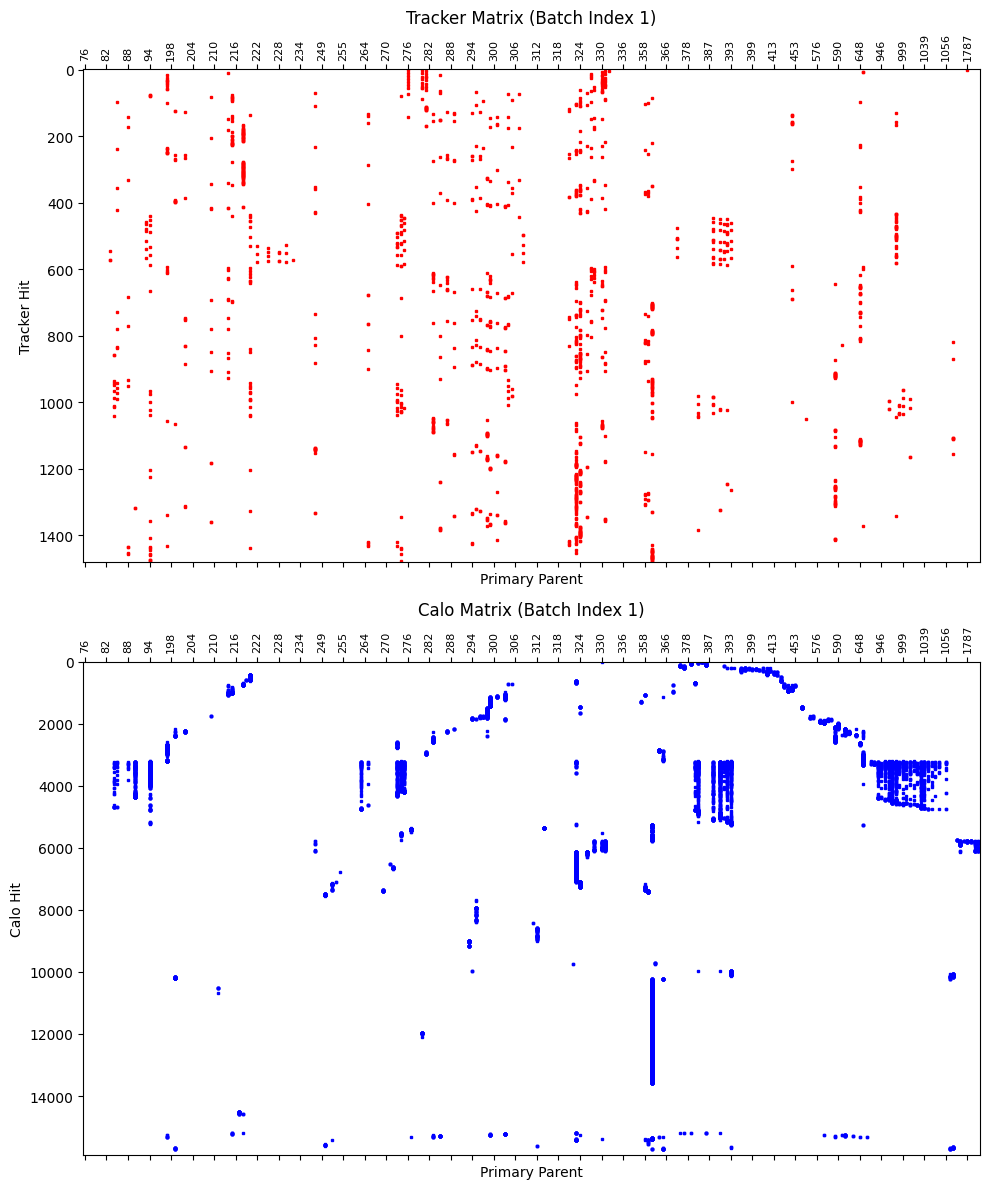

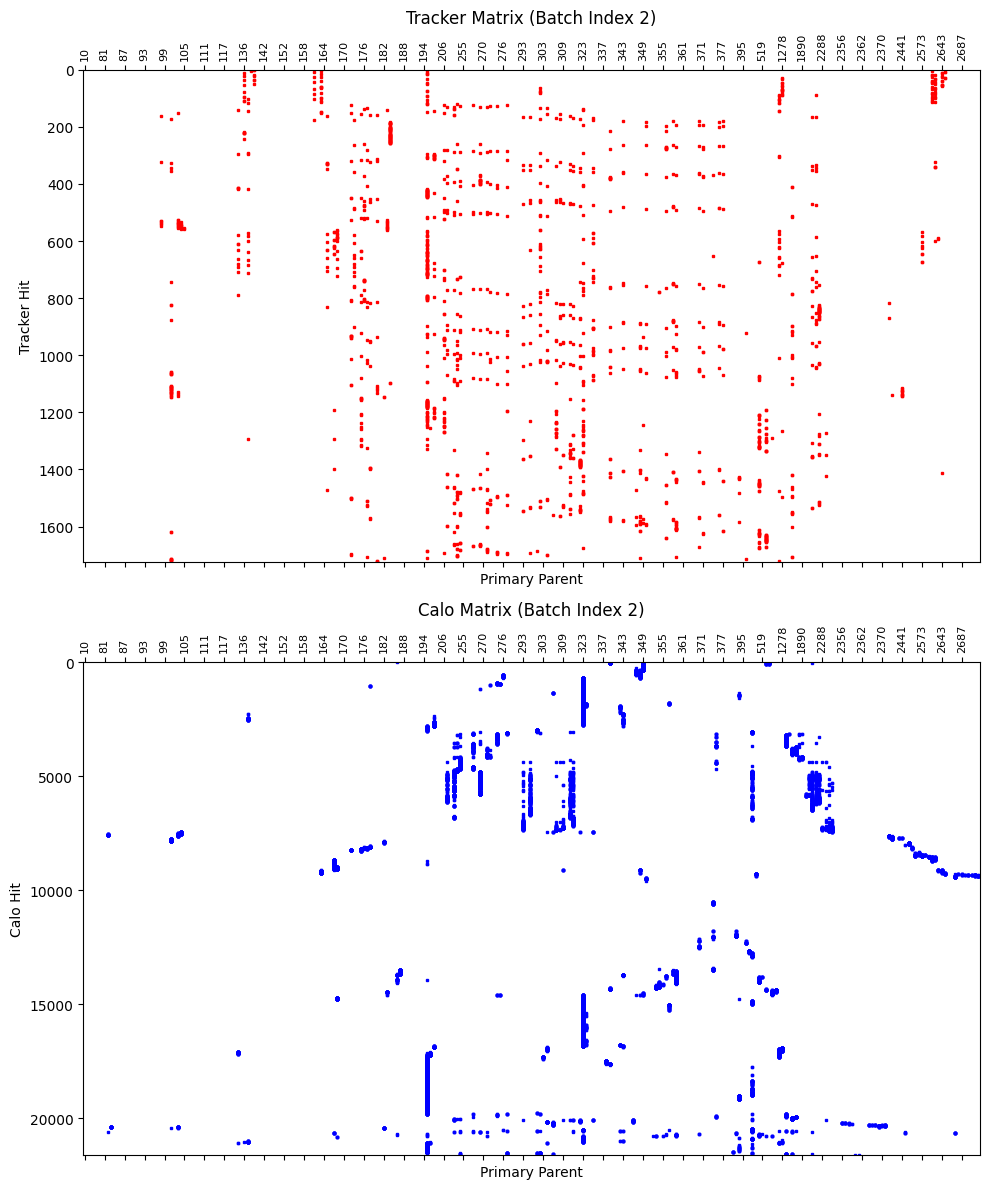

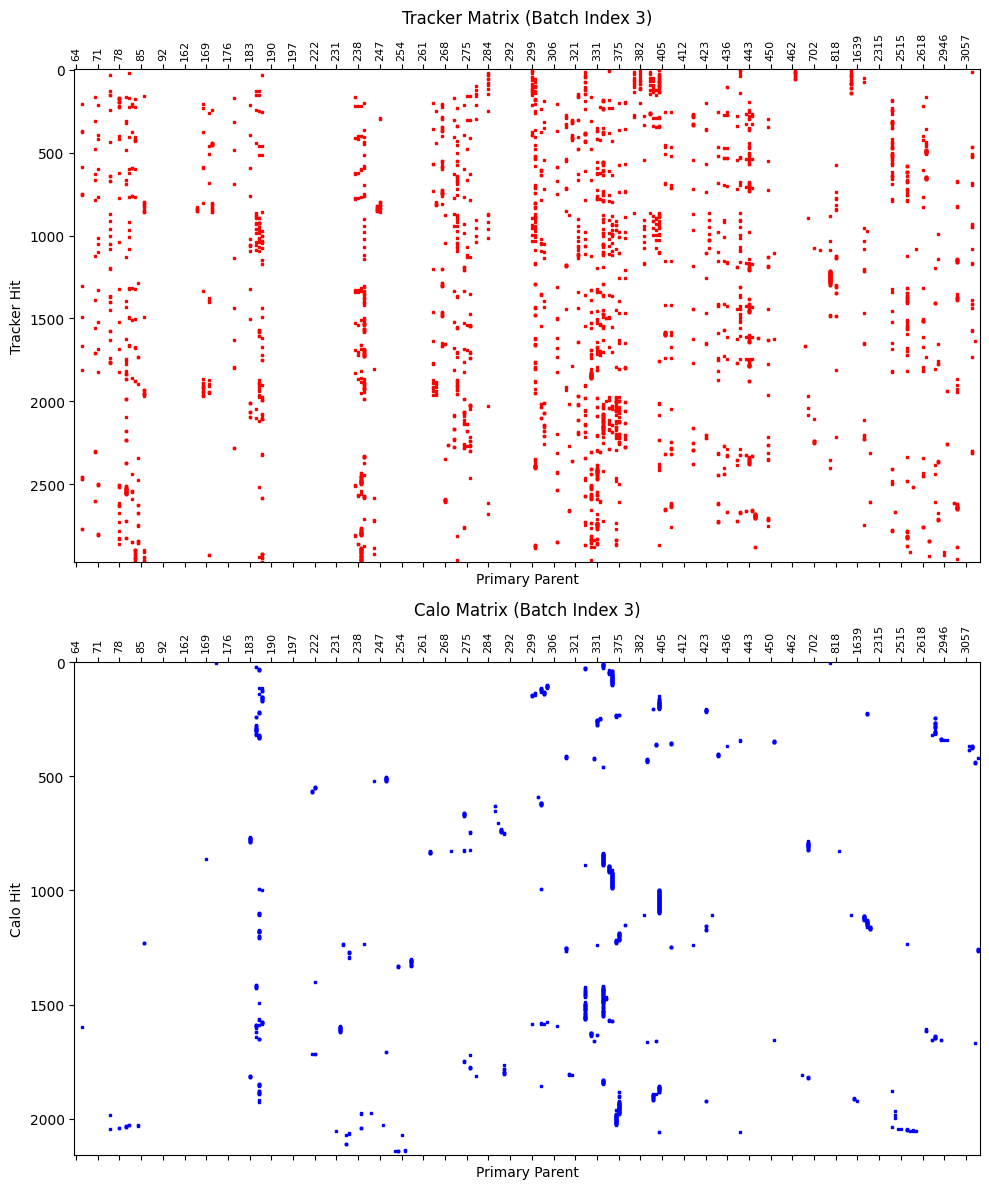

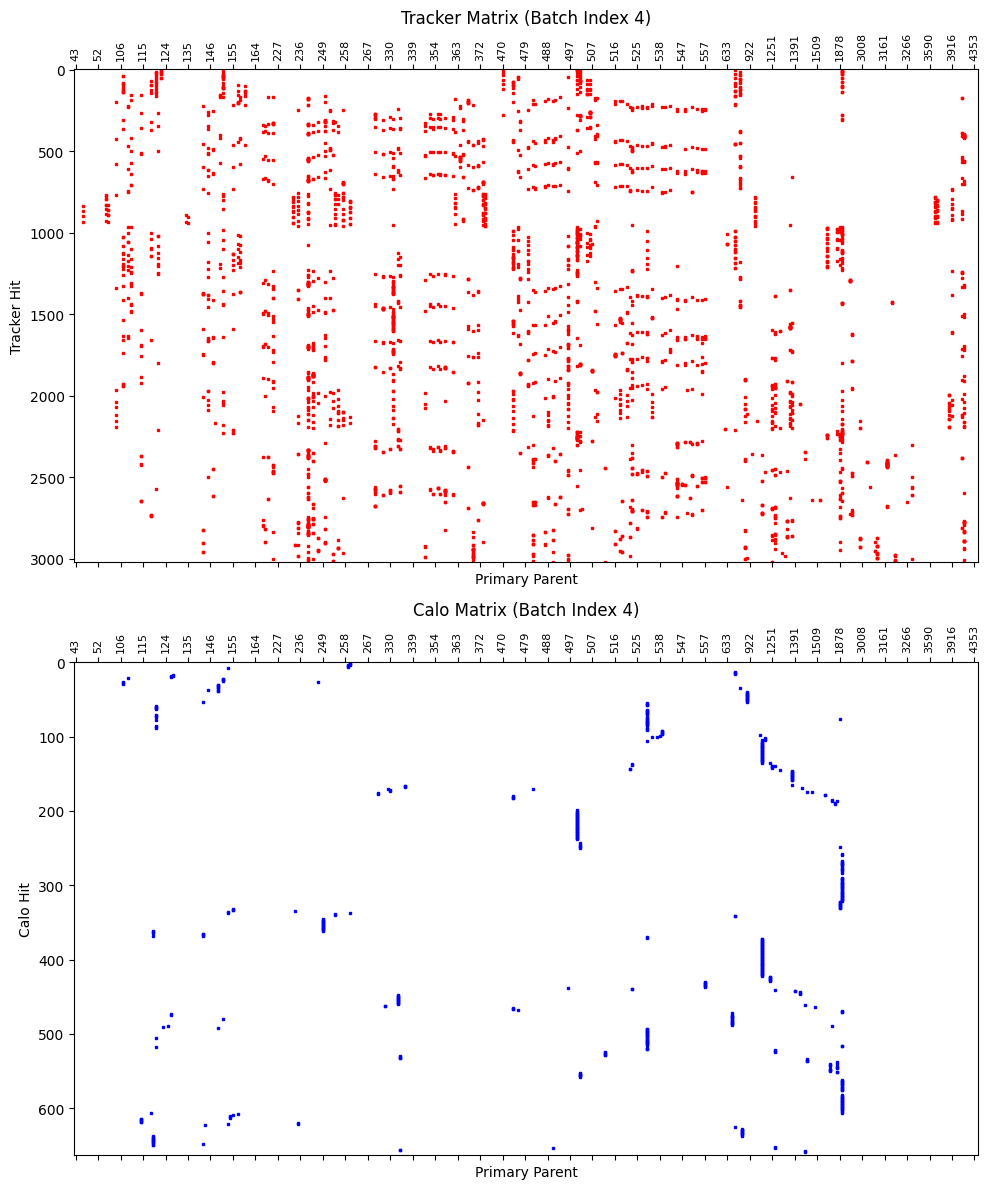

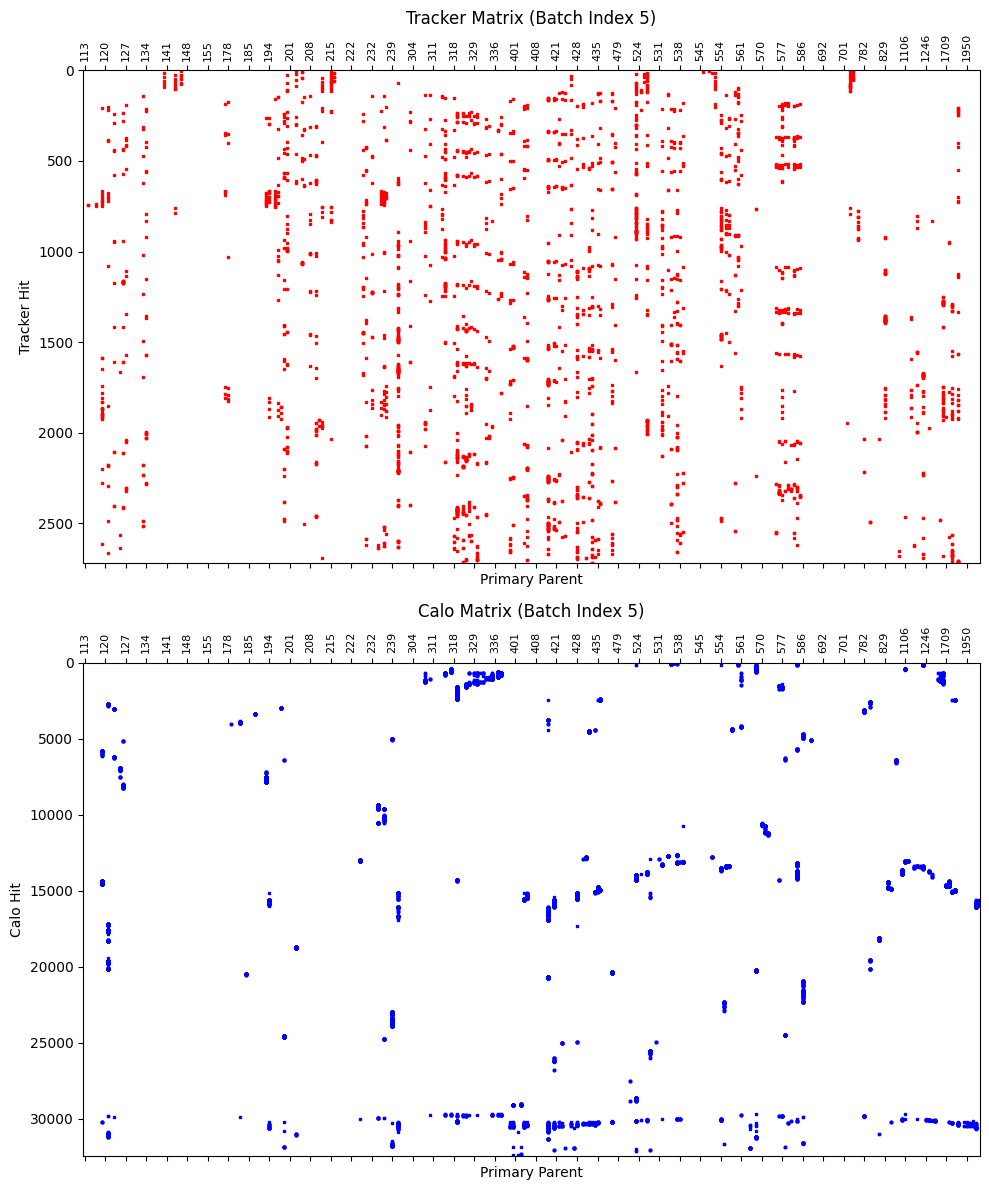

In [3]:
# Fetch the next 5 processed events
results = get_next_batch_of_results(stream_iterator, batch_size=5)

if results is None:
    print("End of stream")
else:
    print(f"Plotting next {len(results)} events...")
    for i, (t_mat, c_mat, unique_pids, pid_map) in enumerate(results):
        fig, axes = plt.subplots(2, 1, figsize=(10, 12))
        
        # Plot Tracker
        axes[0].spy(t_mat, markersize=2, aspect='auto', color='red')
        axes[0].set_title(f'Tracker Matrix (Batch Index {i+1})')
        axes[0].set_ylabel('Tracker Hit')
        axes[0].set_xlabel('Primary Parent')
        
        # Plot Calo
        axes[1].spy(c_mat, markersize=2, aspect='auto', color='blue')
        axes[1].set_title(f'Calo Matrix (Batch Index {i+1})')
        axes[1].set_ylabel('Calo Hit')
        axes[1].set_xlabel('Primary Parent')
        
        # X-ticks logic
        num_cols = len(unique_pids)
        if num_cols > 0:
            step = max(1, num_cols // 40)
            ticks = np.arange(0, num_cols, step)
            for ax in axes:
                ax.set_xticks(ticks)
                ax.set_xticklabels(unique_pids[ticks], rotation=90, fontsize=8)

        plt.tight_layout()
        plt.show()